# BINNs: Biologically-Informed Neural Networks
### SIAM Life Sciences 2026 — Deep Learning Part 2, Example 2

---

**Where we are in Part 2:**

| Strategy | Notebook | Key idea |
|---|---|---|
| Mechanistic | Example 0 | A neuron *is* logistic regression |
| Attribution | Example 1 | Grad-CAM shows *where* the model looked |
| **Structural embedding** | **Example 2 (this)** | **Embed known biology; learn what you don't know** |

---

**The biological scenario:**
You believe you have a predator-prey system — Lotka-Volterra — but you don't know the parameters.
You have a short, noisy time series. How do you recover $\alpha, \beta, \gamma, \delta$?

**The BINN answer:** Build a neural network that approximates the trajectory $(x(t), y(t))$
and train it with two losses:
1. **Data loss** — fit the noisy observations.
2. **Biology loss** — the network's output must satisfy the Lotka-Volterra equations.

The biological parameters are *learnable variables* alongside the network weights.
At the end of training you read off $\hat{\alpha}, \hat{\beta}, \hat{\gamma}, \hat{\delta}$ directly.

**Key advantage over derivative-based methods (SINDy, our earlier REINFORCE example):**
We use automatic differentiation to compute $\frac{d}{dt}[\text{network}(t)]$ exactly.
No Savitzky-Golay smoothing. No noise amplification in the derivative.


## 1. Setup


In [11]:
import numpy as np
import tensorflow as tf
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow: 2.20.0
GPU available: False


## 2. Lotka-Volterra Data

The true predator-prey equations are:
$$\dot{x} = \alpha x - \beta xy \qquad \text{(prey grows, predation removes)}$$
$$\dot{y} = \gamma xy - \delta y \qquad \text{(predation converts, predator dies)}$$

True parameters: $\alpha=1.0,\ \beta=0.1,\ \gamma=0.075,\ \delta=1.5$.

We observe a **noisy, short** time series. `NOISE_LEVEL` is tunable — try 0.0, 0.10, 0.30.


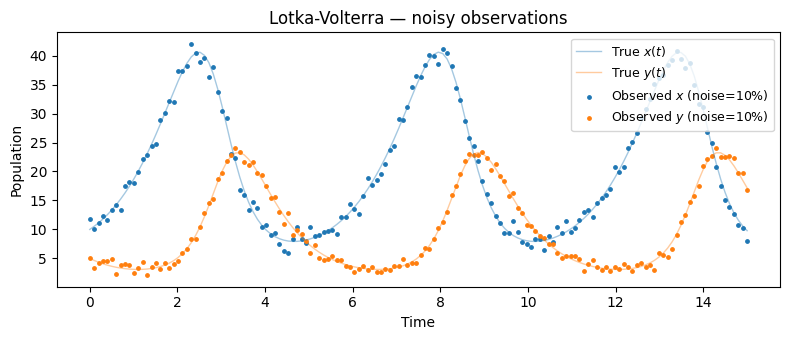

In [12]:
# ── True parameters ───────────────────────────────────────────────────────────
ALPHA_TRUE = 1.00   # prey growth rate
BETA_TRUE  = 0.10   # predation rate
GAMMA_TRUE = 0.075  # conversion efficiency
DELTA_TRUE = 1.50   # predator death rate
x0 = [10.0, 5.0]   # initial conditions (assumed known)

# ── Tunable noise ──────────────────────────────────────────────────────────────
NOISE_LEVEL = 0.10   # fraction of signal std; try 0.0, 0.10, 0.30

# ── Integrate true ODE ────────────────────────────────────────────────────────
t_obs = np.linspace(0, 15, 150)

def true_ode(t, z):
    x, y = z
    return [ALPHA_TRUE*x - BETA_TRUE*x*y,
            GAMMA_TRUE*x*y - DELTA_TRUE*y]

sol = solve_ivp(true_ode, [0, 15], x0, t_eval=t_obs, max_step=0.05)
x_clean, y_clean = sol.y[0], sol.y[1]

np.random.seed(7)
x_data = x_clean + NOISE_LEVEL * np.std(x_clean) * np.random.randn(len(t_obs))
y_data = y_clean + NOISE_LEVEL * np.std(y_clean) * np.random.randn(len(t_obs))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(t_obs, x_clean, 'C0-', lw=1, alpha=0.4, label='True $x(t)$')
ax.plot(t_obs, y_clean, 'C1-', lw=1, alpha=0.4, label='True $y(t)$')
ax.scatter(t_obs, x_data, s=6, c='C0', label=f'Observed $x$ (noise={NOISE_LEVEL:.0%})')
ax.scatter(t_obs, y_data, s=6, c='C1', label=f'Observed $y$ (noise={NOISE_LEVEL:.0%})')
ax.set(xlabel='Time', ylabel='Population', title='Lotka-Volterra — noisy observations')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


## 3. The BINN Architecture

We train a small feed-forward network:
$$\mathcal{N}_{\theta} : t \mapsto \begin{pmatrix} \hat{x}(t) \\ \hat{y}(t) \end{pmatrix}$$

with 3 hidden layers of 32 units and $\tanh$ activations.

Alongside the network weights $\theta$, we learn **four biological parameters**
as unconstrained scalars in log-space (to enforce positivity):
$$\log\alpha,\ \log\beta,\ \log\gamma,\ \log\delta \in \mathbb{R}$$

All 12 + 4 = parameters are updated jointly by Adam.

**Why $\tanh$?** Unlike ReLU, $\tanh$ is smooth and its derivative is well-defined everywhere —
important because we will differentiate the network output with respect to its input $t$.


In [13]:
class LotkaVolterraBINN(tf.keras.Model):
    """
    Biologically-Informed Neural Network for Lotka-Volterra parameter recovery.

    The network N(t) approximates (x(t), y(t)).
    Layers are stored individually (NOT as tf.keras.Sequential) so that
    tf.GradientTape can trace gradients through the network w.r.t. time input t.
    Using Sequential with input_shape creates a hidden InputLayer that breaks
    the gradient tape trace — a known TF2 PINN gotcha.
    """
    def __init__(self, hidden_units=32, n_layers=3):
        super().__init__()
        # ── Individual Dense layers (tanh) ─────────────────────────────────
        self.hidden_layers = [tf.keras.layers.Dense(hidden_units, activation='tanh')
                              for _ in range(n_layers)]
        self.out_layer = tf.keras.layers.Dense(2)   # linear output: (x, y)

        # ── Learnable biological parameters (log-scale → always positive) ─
        init = tf.math.log(0.5)   # starting guess: all params = 0.5
        self.log_alpha = tf.Variable(init, name='log_alpha', dtype=tf.float32)
        self.log_beta  = tf.Variable(init, name='log_beta',  dtype=tf.float32)
        self.log_gamma = tf.Variable(init, name='log_gamma', dtype=tf.float32)
        self.log_delta = tf.Variable(init, name='log_delta', dtype=tf.float32)

    @property
    def alpha(self): return tf.exp(self.log_alpha)
    @property
    def beta(self):  return tf.exp(self.log_beta)
    @property
    def gamma(self): return tf.exp(self.log_gamma)
    @property
    def delta(self): return tf.exp(self.log_delta)

    def call(self, t):
        """Forward pass: t (N,1) → (x(t), y(t)) (N,2)"""
        h = t
        for layer in self.hidden_layers:
            h = layer(h)
        return self.out_layer(h)


# Build model and check
model = LotkaVolterraBINN()
_ = model(tf.constant([[0.0]]))   # trigger weight creation
print(f'Network weights: {sum(tf.size(v).numpy() for v in model.trainable_variables)} total parameters')
print(f'\nInitial parameter guesses:')
print(f'  alpha = {float(model.alpha):.3f}  (true {ALPHA_TRUE})')
print(f'  beta  = {float(model.beta):.3f}  (true {BETA_TRUE})')
print(f'  gamma = {float(model.gamma):.3f}  (true {GAMMA_TRUE})')
print(f'  delta = {float(model.delta):.3f}  (true {DELTA_TRUE})')


Network weights: 2242 total parameters

Initial parameter guesses:
  alpha = 0.500  (true 1.0)
  beta  = 0.500  (true 0.1)
  gamma = 0.500  (true 0.075)
  delta = 0.500  (true 1.5)


## 4. The Two-Part Loss

### Data loss
Fit the noisy observations at times $t_1, \ldots, t_N$:
$$\mathcal{L}_{\text{data}} = \frac{1}{N}\sum_{i=1}^N
\bigl[(\hat{x}(t_i)-x_i^{\text{obs}})^2 + (\hat{y}(t_i)-y_i^{\text{obs}})^2\bigr]$$

### Biology loss
At a dense set of *collocation points* $\{\tau_j\}$, enforce the Lotka-Volterra equations:
$$\mathcal{L}_{\text{bio}} = \frac{1}{M}\sum_{j=1}^M
\left[\left(\frac{d\hat{x}}{dt}\bigg|_{\tau_j} - \alpha\hat{x}_j + \beta\hat{x}_j\hat{y}_j\right)^2
+\left(\frac{d\hat{y}}{dt}\bigg|_{\tau_j} - \gamma\hat{x}_j\hat{y}_j + \delta\hat{y}_j\right)^2\right]$$

The derivative $\frac{d\hat{x}}{dt}$ is computed via **automatic differentiation** (not finite differences):
$$\frac{d}{dt}\mathcal{N}_\theta(t) = J_\theta(t) \qquad \text{(exact, using `tf.GradientTape`)}$$

### Initial condition loss
The initial state is known: $(x(0), y(0)) = (10, 5)$.
$$\mathcal{L}_{\text{ic}} = (\hat{x}(0) - 10)^2 + (\hat{y}(0) - 5)^2$$

### Total loss
$$\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda_{\text{bio}}\,\mathcal{L}_{\text{bio}}
+ \lambda_{\text{ic}}\,\mathcal{L}_{\text{ic}}$$

We train in **two phases**:
- Phase 1 ($\lambda_{\text{bio}}=0$): network learns the rough shape of the trajectory from data alone.
- Phase 2 ($\lambda_{\text{bio}}>0$): physics kicks in, parameter estimates converge.


In [4]:
# ── Prepare tensors ───────────────────────────────────────────────────────────
t_obs_tf  = tf.constant(t_obs.reshape(-1,1),  dtype=tf.float32)
xy_obs_tf = tf.constant(np.column_stack([x_data, y_data]), dtype=tf.float32)
ic_tf     = tf.constant([[x0[0], x0[1]]], dtype=tf.float32)

# Collocation points: denser grid on [0, 15] for physics enforcement
# IMPORTANT: use tf.Variable(trainable=False), NOT tf.constant.
# tf.GradientTape auto-watches Variables; watch() on constants can fail
# when a Sequential InputLayer is present (a known TF2 PINN issue).
N_COLLOC  = 400
t_colloc  = tf.Variable(
    np.linspace(0, 15, N_COLLOC).reshape(-1, 1).astype(np.float32),
    trainable=False, name='t_colloc'
)

# ── Training step ─────────────────────────────────────────────────────────────
def train_step(model, optimizer, lam_bio, lam_ic):
    """One Adam step. Returns (data_loss, bio_loss, ic_loss) as Python floats."""
    with tf.GradientTape() as outer:
        # ── Data loss: fit observations ────────────────────────────────────
        xy_pred   = model(t_obs_tf)
        data_loss = tf.reduce_mean(tf.square(xy_pred - xy_obs_tf))

        # ── IC loss: pin known initial condition ───────────────────────────
        xy_ic   = model(tf.constant([[0.0]]))
        ic_loss = tf.reduce_mean(tf.square(xy_ic - ic_tf))

        # ── Biology loss: enforce LV equations via autodiff ────────────────
        # Inner tape computes d(network)/dt at collocation points.
        # t_colloc is a tf.Variable so it is auto-watched.
        with tf.GradientTape(persistent=True) as inner:
            inner.watch(t_colloc)    # trainable=False vars are NOT auto-watched
            xy_c = model(t_colloc)   # (N_COLLOC, 2)
            x_c  = xy_c[:, 0:1]
            y_c  = xy_c[:, 1:2]

        # Exact time derivatives via chain rule through the network
        dxdt = inner.gradient(tf.reduce_sum(x_c), t_colloc)  # (N_COLLOC, 1)
        dydt = inner.gradient(tf.reduce_sum(y_c), t_colloc)
        del inner

        # LV residuals — should be zero if the ODE is exactly satisfied
        res_x = dxdt - (model.alpha * x_c - model.beta  * x_c * y_c)
        res_y = dydt - (model.gamma * x_c * y_c - model.delta * y_c)
        bio_loss = tf.reduce_mean(tf.square(res_x)) + tf.reduce_mean(tf.square(res_y))

        total = data_loss + lam_bio * bio_loss + lam_ic * ic_loss

    # Gradients only w.r.t. network weights + log-parameters (not t_colloc)
    grads = outer.gradient(total, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return float(data_loss), float(bio_loss), float(ic_loss)


In [5]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
PHASE1_EPOCHS = 1000   # data only
PHASE2_EPOCHS = 4000   # data + biology
LAM_BIO       = 0.01   # physics weight
LAM_IC        = 1.0    # IC weight
LR            = 1e-3

model     = LotkaVolterraBINN()
optimizer = tf.keras.optimizers.Adam(LR)

hist = {'data':[], 'bio':[], 'ic':[], 'phase':[]}
PRINT_EVERY = 500

print('=== Phase 1: data loss only ===')
for ep in range(1, PHASE1_EPOCHS + 1):
    dl, bl, il = train_step(model, optimizer, lam_bio=0.0, lam_ic=LAM_IC)
    hist['data'].append(dl); hist['bio'].append(bl); hist['ic'].append(il)
    hist['phase'].append(1)
    if ep % PRINT_EVERY == 0:
        print(f'  ep {ep:4d}  data={dl:.4f}  ic={il:.4f}')
        print(f'          α={float(model.alpha):.3f} β={float(model.beta):.3f} '
              f'γ={float(model.gamma):.3f} δ={float(model.delta):.3f}')

print('\n=== Phase 2: data + biology loss ===')
for ep in range(1, PHASE2_EPOCHS + 1):
    dl, bl, il = train_step(model, optimizer, lam_bio=LAM_BIO, lam_ic=LAM_IC)
    hist['data'].append(dl); hist['bio'].append(bl); hist['ic'].append(il)
    hist['phase'].append(2)
    if ep % PRINT_EVERY == 0:
        print(f'  ep {ep:4d}  data={dl:.4f}  bio={bl:.4f}  ic={il:.4f}')
        print(f'          α={float(model.alpha):.3f} β={float(model.beta):.3f} '
              f'γ={float(model.gamma):.3f} δ={float(model.delta):.3f}')

print('\nDone.')


In [ ]:
epochs = np.arange(1, PHASE1_EPOCHS + PHASE2_EPOCHS + 1)
phase_switch = PHASE1_EPOCHS

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, key, title in zip(axes,
                           ['data', 'bio', 'ic'],
                           ['Data loss', 'Biology loss (LV residual)', 'IC loss']):
    ax.semilogy(epochs, hist[key], lw=1.2, color='steelblue')
    ax.axvline(phase_switch, color='tomato', lw=1.5, ls='--', label='Phase 2 begins')
    ax.set(xlabel='Epoch', title=title)
    ax.legend(fontsize=8)

plt.suptitle('BINN training curves', fontsize=12)
plt.tight_layout(); plt.show()


## 5. Results


In [ ]:
# ── Recovered vs true parameters ─────────────────────────────────────────────
params = {
    'alpha': (float(model.alpha), ALPHA_TRUE),
    'beta' : (float(model.beta),  BETA_TRUE),
    'gamma': (float(model.gamma), GAMMA_TRUE),
    'delta': (float(model.delta), DELTA_TRUE),
}

print(f'{'Parameter':>10}  {'Recovered':>10}  {'True':>8}  {'Error':>8}')
print('-' * 45)
for name, (rec, true) in params.items():
    err = abs(rec - true) / true * 100
    print(f'{name:>10}  {rec:>10.4f}  {true:>8.4f}  {err:>7.1f}%')

# ── Bar chart ─────────────────────────────────────────────────────────────────
labels = list(params.keys())
rec_vals  = [params[k][0] for k in labels]
true_vals = [params[k][1] for k in labels]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(x - 0.2, true_vals,  0.35, label='True',      color='steelblue', alpha=0.8)
ax.bar(x + 0.2, rec_vals,   0.35, label='Recovered',  color='tomato',    alpha=0.8)
ax.set(xticks=x, xticklabels=[f'$\\{l}$' for l in labels],
       ylabel='Value', title='BINN: recovered vs true biological parameters')
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
# ── Recovered trajectory ──────────────────────────────────────────────────────
t_dense = np.linspace(0, 15, 500).reshape(-1, 1).astype(np.float32)
xy_pred = model.net(tf.constant(t_dense)).numpy()
x_pred, y_pred = xy_pred[:, 0], xy_pred[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, label, x_tr, x_pr, x_ob in zip(
        axes,
        ['Prey $x(t)$', 'Predator $y(t)$'],
        [x_clean, y_clean],
        [x_pred,  y_pred],
        [x_data,  y_data]):
    ax.scatter(t_obs, x_ob, s=8, alpha=0.5, label='Noisy observations')
    ax.plot(t_obs, x_tr, 'k-',  lw=1, alpha=0.4, label='True trajectory')
    ax.plot(t_dense, x_pr, 'tomato', lw=2, label='BINN fit')
    ax.set(xlabel='Time', title=label)
    ax.legend(fontsize=8)

plt.suptitle(f'BINN trajectory recovery  (noise={NOISE_LEVEL:.0%})', fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ── Phase portrait (x vs y) ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(x_data, y_data, s=8, alpha=0.4, label='Noisy observations')
ax.plot(x_clean, y_clean, 'k-', lw=1, alpha=0.4, label='True orbit')
ax.plot(x_pred,  y_pred,  'tomato', lw=2, label='BINN orbit')
ax.set(xlabel='Prey $x$', ylabel='Predator $y$',
       title='Phase portrait: BINN vs true')
ax.legend(); plt.tight_layout(); plt.show()


## 6. Discussion

### What the BINN learned

The network learned two things simultaneously:
- A smooth function $\mathcal{N}(t) \approx (x(t), y(t))$ that fits the noisy data.
- Four biological parameters $\hat{\alpha}, \hat{\beta}, \hat{\gamma}, \hat{\delta}$ that
  make the ODE residual small.

Neither could be learned without the other: without the biology loss, the network
has no reason to converge to the true parameters. Without the data, the parameters
are unidentifiable from the ODE alone (infinitely many solutions).

### Why automatic differentiation beats Savitzky-Golay

In SINDy and our earlier REINFORCE example, derivatives of the noisy data are estimated
numerically using Savitzky-Golay smoothing. This works at low noise but saturates at ~30–50%.

The BINN never differentiates the *data*. Instead it differentiates the *network*:
$$\frac{d}{dt}\mathcal{N}_\theta(t) = \text{exact, via chain rule through the network}$$
This derivative is smooth and noise-free — it's a property of the learned function,
not of the data. The noise in the data enters only through the data loss term.

### Limitations

- **You must know the equation structure.** If you don't know it's Lotka-Volterra,
  BINNs cannot discover this for you. (That's what methods like SINDy and DSO are for.)
- **Collocation point placement matters.** Too few collocation points and the physics
  is under-enforced in parts of the domain.
- **Physics weight $\lambda_{\text{bio}}$ needs tuning.** Too high and the network ignores
  data; too low and the parameters don't converge.
- **Training can be sensitive to initialisation** — a common challenge with PINNs.

### Exercises
1. Set `NOISE_LEVEL = 0.30` and re-run. Does the BINN still recover the parameters?
   Compare to what happens with SINDy at this noise level.
2. Mis-specify the model: remove the $xy$ term from $\dot{y}$ (use $-\delta y$ only).
   What happens to the trajectory fit and the parameters?
3. Change `LAM_BIO` from 0.01 to 0.001 or 0.1. How does this affect parameter recovery?
4. What happens if you skip Phase 1 entirely (start with physics from epoch 1)?


---
## 7. Connection to the Tutorial

BINNs sit at the intersection of two ideas from this tutorial:

| | Logistic regression (Pt 1) | BINN (this notebook) |
|---|---|---|
| Model class | Known (linear) | Known (LV equations) |
| Parameters | Fit by MLE / gradient descent | Fit by gradient descent |
| Output | Coefficients $w_k$ | Parameters $\alpha, \beta, \gamma, \delta$ |
| Interpretability | Read off the weights | Read off the biology |

The difference is that Part 1 used a *statistical* model you could write down analytically.
Here the model is a *mechanistic ODE* — and the neural network is used not for prediction
but as a smooth surrogate for the unknown solution.

**The key shift**: in deep learning, interpretability doesn't have to mean
'inspect the network weights.' It can mean 'use the network as a tool to extract
something you already cared about' — in this case, biological rate parameters.

### Further reading
- Lagergren et al. (2020). *Biologically-informed neural networks guide mechanistic
  modeling from sparse experimental data.* PLOS Computational Biology.
  [[paper]](https://doi.org/10.1371/journal.pcbi.1008462)
- Raissi, Perdikaris & Karniadakis (2019). *Physics-informed neural networks.*
  Journal of Computational Physics. [[paper]](https://doi.org/10.1016/j.jcp.2018.10.045)
- Brunton & Kutz (2022). *Data-Driven Science and Engineering.* Cambridge.
  (Covers SINDy, PINNs, and equation learning in a unified framework.)
